## **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Loading Dataset**

In [2]:
df = pd.read_csv("Algerian_forest_fires_cleaned_dataset.csv")

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1.0,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2.0,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3.0,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4.0,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5.0,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

#### Dropping Unneccessary Features

In [5]:
df.drop(['day', 'month', 'year'], axis=1, inplace=True)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


## **Encoding**

In [6]:
df["Classes"].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [7]:
df["Classes"] = np.where(df["Classes"].str.contains("not fire"), 0, 1)

In [8]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [9]:
df["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

## **Independent and Dependent Features**

In [10]:
X = df.drop("FWI" ,axis=1) # independent
y = df["FWI"] # dependent

In [11]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [12]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

## **Train Test Split**

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=42
                                                    ) 

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((182, 11), (61, 11), (182,), (61,))

## **Feature Selection based on Correlation**

In [15]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


#### Check for Multicollinearity

<Axes: >

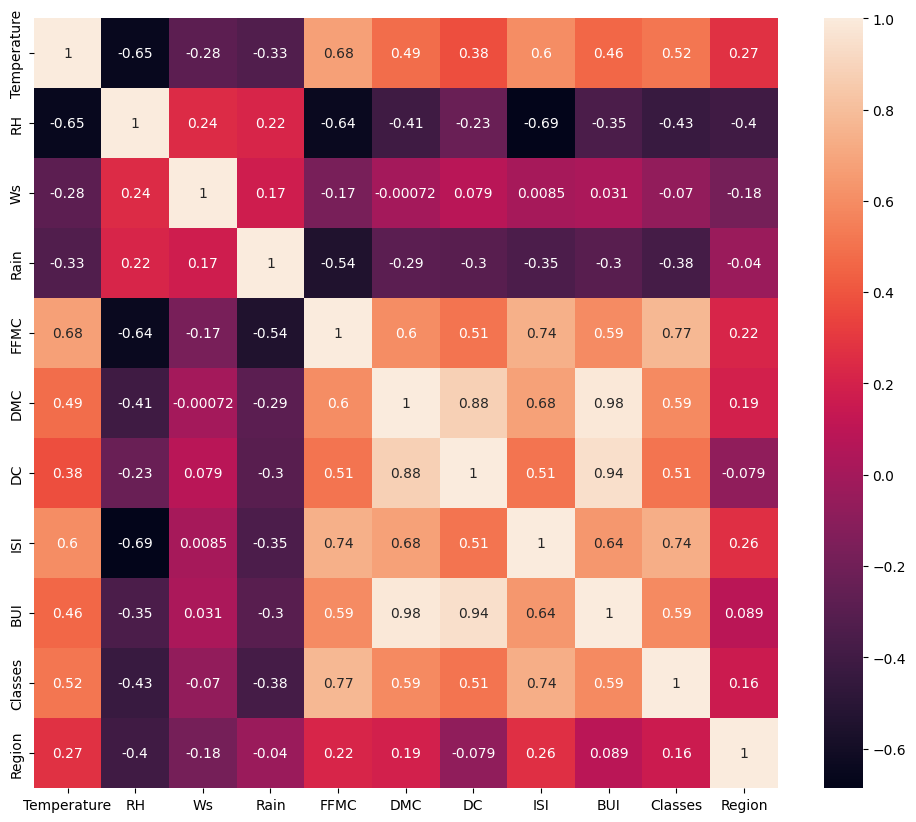

In [16]:
plt.figure(figsize=(12,10))
corr = X.corr()
sns.heatmap(corr, annot=True)

In [17]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [18]:
corr_features = correlation(X_train, 0.85)
corr_features

{'BUI', 'DC'}

#### Dropping the features where correlation is more than 85%

In [19]:
X_train.drop(corr_features, axis=1, inplace=True)
X_test.drop(corr_features, axis=1, inplace=True)
X_train.shape, X_test.shape

((182, 9), (61, 9))

## **Feature Scaling or Standardization**

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
X_test_scaled

array([[-3.01758418e-01,  1.15223531e-01, -2.19053977e-01,
        -3.84060174e-01,  6.33218240e-01, -4.25075679e-02,
         2.03772218e-01,  9.05538514e-01, -9.89070710e-01],
       [ 2.39325642e-01, -5.52632606e-01, -9.78441098e-01,
        -3.84060174e-01,  7.37980727e-01, -3.83352062e-01,
         3.65823283e-01,  9.05538514e-01, -9.89070710e-01],
       [-1.11338451e+00, -2.85490151e-01,  9.20026704e-01,
         6.45241658e-01, -9.73139891e-01, -9.14435344e-01,
        -8.37984627e-01, -1.10431526e+00,  1.01105006e+00],
       [ 5.09867672e-01, -2.85490151e-01, -9.78441098e-01,
        -2.90487280e-01,  1.30358303e-01,  3.14190159e-01,
        -6.29633258e-01, -1.10431526e+00,  1.01105006e+00],
       [-5.72300448e-01,  1.82009145e-01, -5.98747538e-01,
        -3.84060174e-01,  5.42424085e-01,  1.00171523e-01,
        -7.40296073e-02,  9.05538514e-01,  1.01105006e+00],
       [ 1.86257782e+00,  1.15223531e-01, -2.49721534e+00,
         1.77377189e-01, -2.67739147e-01, -2.406729

## **Box Plot to understand Effect of Standard Scaler**

Text(0.5, 1.0, 'X_train After Scaling')

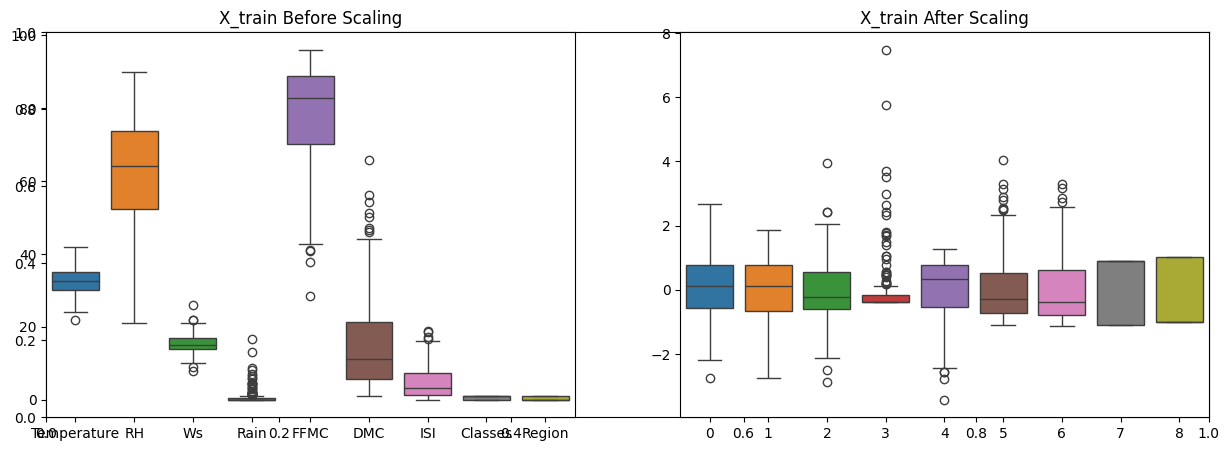

In [22]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train Before Scaling")

plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_train After Scaling")

## **Linear Regression**

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [24]:
# Training
linear_regression = LinearRegression()
linear_regression.fit(X_train_scaled, y_train)

# Predicting
y_pred_linear_regression = linear_regression.predict(X_test_scaled)

MAE = 0.546823646524997
R2 Score = 0.9847657384266951


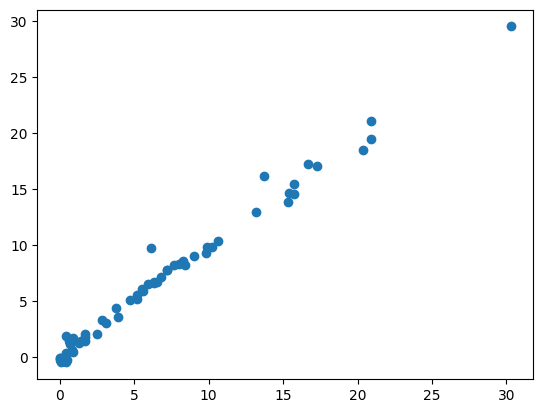

In [25]:
# Scoring
mae_linear_regression = mean_absolute_error(y_test, y_pred_linear_regression)
score_linear_regression = r2_score(y_test, y_pred_linear_regression)

print(f"MAE = {mae_linear_regression}")
print(f"R2 Score = {score_linear_regression}")

# Plotting Scores
plt.scatter(y_test, y_pred_linear_regression)

## **Lasso Regression**

In [26]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [27]:
# Training
lasso_regression = Lasso()
lasso_regression.fit(X_train_scaled, y_train)

# Predicting
y_pred_lasso_regression = lasso_regression.predict(X_test_scaled)

MAE = 1.133175994914409
R2 Score = 0.9492020263112388


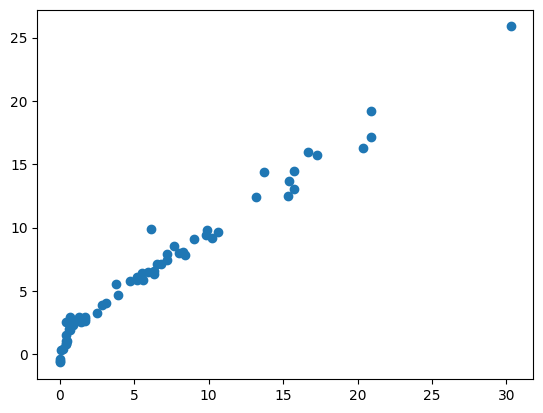

In [28]:
# Scoring
mae_lasso_regression = mean_absolute_error(y_test, y_pred_lasso_regression)
score_lasso_regression = r2_score(y_test, y_pred_lasso_regression)

print(f"MAE = {mae_lasso_regression}")
print(f"R2 Score = {score_lasso_regression}")

# Plotting Scores
plt.scatter(y_test, y_pred_lasso_regression)

#### **Cross Validation Lasso Regression**

In [41]:
# Training
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5)
lasso_cv.fit(X_train_scaled, y_train)

# Predict
y_pred_lasso_cv = lasso_cv.predict(X_test_scaled)

MAE = 0.6199701158263431
R2 Score = 0.9820946715928275


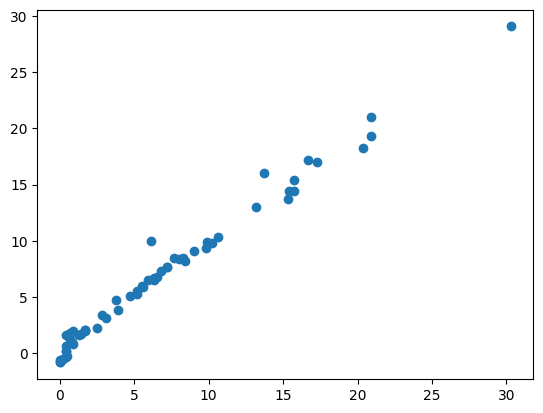

In [42]:
# Scoring
mae_lasso_cv = mean_absolute_error(y_test, y_pred_lasso_cv)
score_lasso_cv = r2_score(y_test, y_pred_lasso_cv)

print(f"MAE = {mae_lasso_cv}")
print(f"R2 Score = {score_lasso_cv}")

# Plotting Scores
plt.scatter(y_test, y_pred_lasso_cv)

## **Ridge Regression**

In [43]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [44]:
# Training
ridge_regression = Ridge()
ridge_regression.fit(X_train_scaled, y_train)

# Predicting
y_pred_ridge = ridge_regression.predict(X_test_scaled)

MAE = 0.5642305340105691
Score = 0.9842993364555513


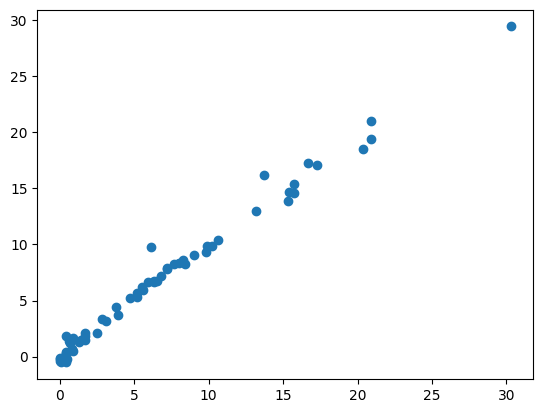

In [45]:
# Scoring
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
score_ridge = r2_score(y_test, y_pred_ridge)

print(f"MAE = {mae_ridge}")
print(f"Score = {score_ridge}")

# Plotting Scores
plt.scatter(y_test, y_pred_ridge)

#### **Cross Validation Ridge Regression**

In [46]:
from sklearn.linear_model import RidgeCV

# Training
ridge_cv = RidgeCV(cv=5)
ridge_cv.fit(X_train_scaled, y_train)

# Predicting
y_pred_ridge_cv = ridge_cv.predict(X_test_scaled)

MAE = 0.5642305340105691
Score = 0.9842993364555513


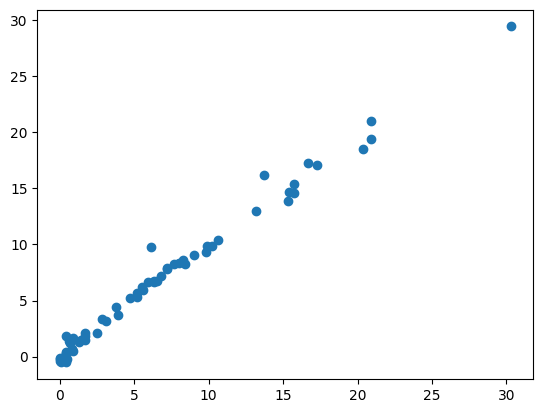

In [47]:
# Scoring
mae_ridge_cv = mean_absolute_error(y_test, y_pred_ridge_cv)
score_ridge = r2_score(y_test, y_pred_ridge_cv)

print(f"MAE = {mae_ridge}")
print(f"Score = {score_ridge}")

# Plotting Scores
plt.scatter(y_test, y_pred_ridge_cv)

In [48]:
ridge_cv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

## **Ridge Regression**

In [49]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [52]:
# Training
elastic_net = ElasticNet()
elastic_net.fit(X_train_scaled, y_train)

# Predicting
y_pred_elastic_net = elastic_net.predict(X_test_scaled)

MAE = 1.8822353634896
R2 Score = 0.8753460589519703


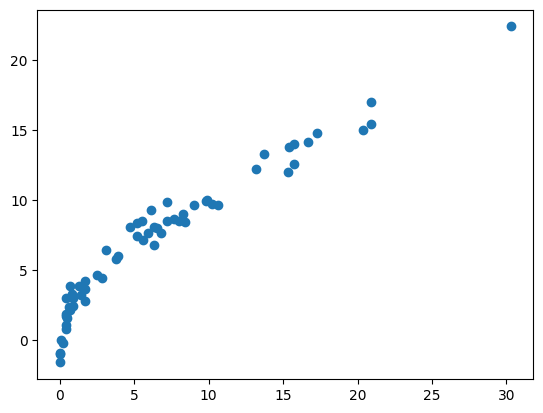

In [53]:
# Scoring
mae_elastic_net = mean_absolute_error(y_test, y_pred_elastic_net)
score_elastic_net = r2_score(y_test, y_pred_elastic_net)

print(f"MAE = {mae_elastic_net}")
print(f"R2 Score = {score_elastic_net}")

# Plotting Scores
plt.scatter(y_test, y_pred_elastic_net)

#### **Cross Validation Elastic Net**

In [54]:
from sklearn.linear_model import ElasticNetCV

# Training
elastic_net_cv = ElasticNetCV(cv=5)
elastic_net_cv.fit(X_train_scaled, y_train)

# Predicting
y_pred_elastic_net_cv = elastic_net_cv.predict(X_test_scaled)

MAE = 0.6575946731430901
R2 Score = 0.9814217587854941


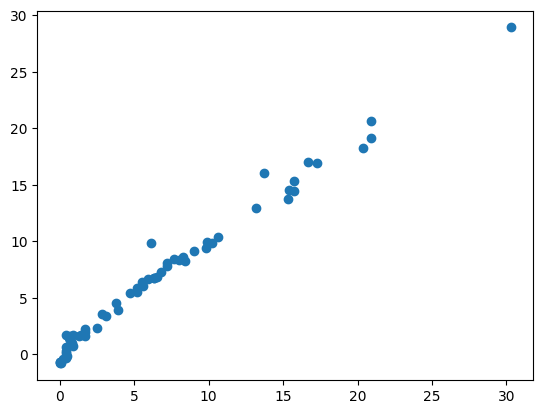

In [55]:
# Scoring
mae_elastic_net_cv = mean_absolute_error(y_test, y_pred_elastic_net_cv)
score_elastic_net_cv = r2_score(y_test, y_pred_elastic_net_cv)

print(f"MAE = {mae_elastic_net_cv}")
print(f"R2 Score = {score_elastic_net_cv}")

# Plotting Scores
plt.scatter(y_test, y_pred_elastic_net_cv)

In [56]:
elastic_net_cv.get_params()

{'alphas': 'warn',
 'copy_X': True,
 'cv': 5,
 'eps': 0.001,
 'fit_intercept': True,
 'l1_ratio': 0.5,
 'max_iter': 1000,
 'n_alphas': 'deprecated',
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': 0}

## **Pickling ML Models, Preprocessing Models (Standard Scaler)**

In [57]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [58]:
ridge_regression

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [60]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(ridge_regression, open('ridge.pkl', 'wb'))